In [1]:
# Load libraries

%load_ext autoreload
%autoreload 2

import pandas as pd
print("success: pandas")
import numpy as np
print("success: numpy")
import matplotlib.pyplot as plt
print("success: matplotlib")
import sklearn as sk
print("success: sklearn")
import seaborn as sns
print("success: c'est bon")
from pathlib import Path
import mlsnips_v2 as mu
dataset_filepath = Path('.') / 'datasets' / 'train.csv'
df_train_main = pd.read_csv(dataset_filepath)

success: pandas
success: numpy
success: matplotlib
success: sklearn
success: c'est bon


In [ ]:
mu.eda_inspect_df(X=df_train_main)

In [ ]:
mu.get_grouped_colnames(df_train_main)

In [ ]:
df_train_main.iloc[123456:123461]

Seems like `ID_code` is irrelevant here. I'll drop it now.

In [2]:
df_train_main = df_train_main.drop(columns=["ID_code"])

In [ ]:
print(df_train_main.shape)
df_train_main.iloc[123456:123461]

In [ ]:
mu.get_grouped_colnames(df=df_train_main)

Please, no missing values...

In [3]:
df_train_main.isna().sum().sum()
# YIPPEE

np.int64(0)

In [ ]:
mu.graph_onecat_hist(df_train_main, "target", incl_percentage=True)

In [ ]:
col_stats = df_train_main.describe().T
n_rows = len(df_train_main)

top_value_ratio = df_train_main.apply(
    lambda s: s.value_counts(normalize=True, dropna=False).iloc[0]
)
col_stats["top_value_ratio"] = top_value_ratio

n_unique = df_train_main.nunique(dropna=False)
col_stats["n_unique"] = n_unique

n_unique_ratio = n_unique / n_rows
col_stats["n_unique_ratio"] = n_unique_ratio

var = df_train_main.var()
col_stats["var"] = var

cv = df_train_main.std() / df_train_main.mean().abs()
col_stats["cv"] = cv

percentiles = df_train_main.quantile(
    [0.01, 0.05, 0.95, 0.99]
).T
percentiles.columns = ["p01", "p05", "p95", "p99"]
col_stats = col_stats.join(percentiles)

col_stats

In [ ]:
col_stats.to_csv(r"./datasets/df-train-describe.csv")

- `68` low cv, drop
- `45,74,117,90,120,149,97` tail heavy, compressed bulk

In [4]:
drop_colnames = ["var_68"]
investigate_colnames = ["var_45","var_74","var_117","var_90","var_120","var_149","var_97"]

In [5]:
from sklearn.metrics import roc_auc_score

df_train_feats = df_train_main.drop(columns=["target"])
df_train_preds = df_train_main["target"]

In [ ]:
results = []
for col in df_train_feats.columns:
    try:
        auc = roc_auc_score(df_train_preds, df_train_feats[col])
        results.append((col, auc))
    except ValueError:
        results.append((col, None))

univariate_auc = pd.DataFrame(results, columns=["feature", "univariate_auc"])
univariate_auc.sort_values("univariate_auc", ascending=False, inplace=True)

In [ ]:
print("Columns with univariate AUC > 0.54: ")
print(univariate_auc[univariate_auc["univariate_auc"] > 0.54].shape)
univariate_auc[univariate_auc["univariate_auc"] > 0.54]

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "logistic_l2": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l2",
            class_weight="balanced",
            solver="lbfgs",
            max_iter=1000,
            random_state=42
        ))
    ]),

    "logistic_elasticnet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="elasticnet",
            class_weight="balanced",
            solver="saga",
            l1_ratio=0.5,   # baseline value; tune later
            C=1.0,
            max_iter=2000,
            random_state=42
        ))
    ]),

    "gaussian_nb": GaussianNB(),

    "decision_tree": DecisionTreeClassifier(
        max_depth=6,          # shallow baseline
        min_samples_leaf=20,
        random_state=42
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced_subsample",
        max_depth=15,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=42
    )
}

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    df_train_feats.drop(columns=drop_colnames), df_train_preds, test_size=0.2, random_state=42,
    stratify=df_train_preds # REMEMBER TO STRATIFY!!!!
)

In [11]:
X_val

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
199837,8.7757,6.7905,9.2920,4.8443,10.8877,3.5858,4.7267,14.1264,1.9131,7.1682,...,4.8996,4.4960,2.0201,5.0578,18.7864,-0.2550,4.0958,7.9291,17.6055,-7.4019
149409,7.5491,-8.4764,15.4626,3.6803,12.1527,-7.1858,5.1952,13.7568,2.5632,8.1126,...,10.2822,11.9053,3.0869,-0.6879,22.3453,-2.1595,4.1147,9.2685,12.2069,1.3086
43642,5.8385,-6.9177,8.1589,6.7591,9.0635,4.9003,4.7126,21.1854,-3.5385,8.3261,...,0.0732,10.2627,-0.3105,6.8481,15.2119,-0.5050,1.8873,8.6977,18.6569,11.5001
157332,15.6901,-7.7904,8.3676,6.3246,9.8144,6.9361,4.5284,11.7888,3.3775,8.8897,...,11.8331,4.3828,2.9730,2.4989,18.6336,1.0621,-3.8953,8.7950,12.9313,-3.1393
189470,15.5726,-6.6387,12.0251,7.2093,10.3838,-8.9961,4.8868,18.8259,-5.2734,7.3476,...,7.9042,10.4118,3.3438,0.4358,16.0511,0.7758,-3.3334,7.7918,18.2619,-3.2074
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7751,13.9605,1.6317,16.5365,5.5922,12.2347,-14.3060,5.0389,18.4215,4.0158,7.0972,...,-1.3783,8.9957,2.2425,9.3388,14.8871,0.8290,-1.0208,8.3668,16.5769,2.4484
112628,7.4985,4.7339,11.9952,6.2574,9.8171,4.6362,4.6372,13.3072,-0.5075,8.3850,...,5.5200,9.0240,2.1368,4.9087,16.1938,0.5539,6.7445,10.1029,20.6326,-19.7800
71398,4.5195,3.8886,7.4813,8.1466,11.8629,-4.4444,5.1001,23.0027,-3.2955,6.2351,...,7.0380,3.5980,1.9735,3.4259,15.9605,1.0190,3.0311,6.7328,15.8304,-2.2132
39497,8.8422,3.3068,8.3702,9.4941,11.5611,13.2109,5.3921,11.9120,-2.1810,5.9458,...,7.4395,10.4932,3.7310,11.7952,17.9021,-1.4007,-6.2355,9.4922,14.9396,-9.6255


logistic_l2 model trained in 3.3163790702819824 seconds.
logistic_elasticnet model trained in 75.24291968345642 seconds.
gaussian_nb model trained in 1.566650152206421 seconds.
decision_tree model trained in 62.9884889125824 seconds.
random_forest model trained in 265.15300369262695 seconds.


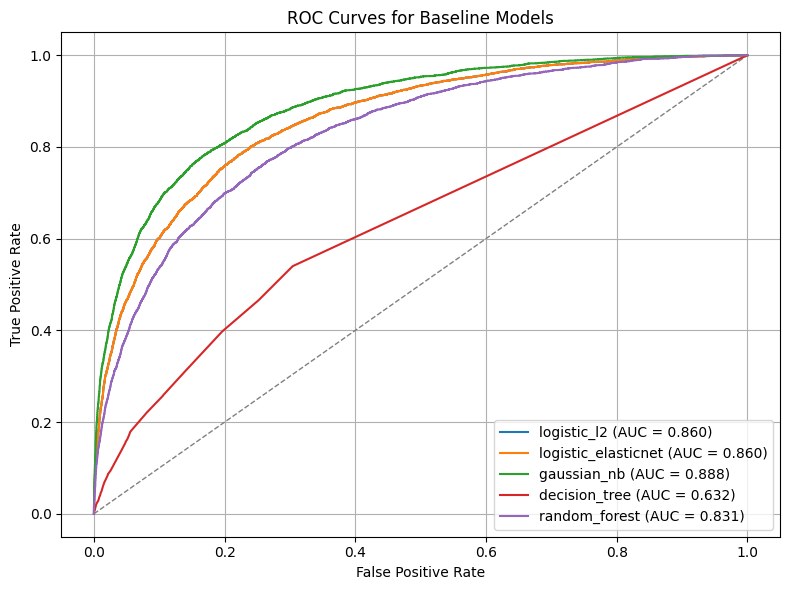

In [10]:
from sklearn.metrics import roc_auc_score, roc_curve
import time

roc_results = {}

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

for name, model in models.items():
    st = time.time()
    model.fit(X_train, y_train)
    print(f"{name} model trained in {time.time()-st} seconds.")

    y_proba = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_proba)
    fpr, tpr, _ = roc_curve(y_val, y_proba)

    roc_results[name] = {
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr
    }

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Baseline Models")
plt.legend(loc="lower right")   # Legend shows model name + AUC
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
gnb = models["gaussian_nb"]

means = gnb.theta_
vars_ = gnb.var_

mean_diff = np.abs(means[0] - means[1])
var_sum = vars_[0] + vars_[1]

nb_signal = mean_diff / np.sqrt(var_sum)

nb_importance = pd.Series(
    nb_signal,
    index=X_train.columns
).sort_values(ascending=False)
nb_importance.head(15)

var_81     0.182856
var_139    0.174458
var_12     0.157911
var_6      0.154792
var_110    0.148908
var_76     0.144077
var_146    0.143881
var_53     0.143639
var_26     0.143253
var_174    0.141980
var_22     0.136032
var_166    0.132762
var_190    0.132090
var_21     0.131219
var_99     0.131045
dtype: float64

In [14]:
logit = models["logistic_l2"]
coef = logit.named_steps["model"].coef_[0]
logit_coef = pd.Series(
    coef,
    index=X_train.columns
).sort_values(key=abs, ascending=False)
logit_coef.head(15)

var_81    -0.243007
var_139   -0.229125
var_6      0.217057
var_12    -0.210134
var_53     0.208003
var_110    0.205531
var_76    -0.205180
var_146   -0.199910
var_174   -0.195506
var_26     0.194863
var_22     0.192525
var_99     0.188809
var_190    0.183424
var_34    -0.181009
var_21    -0.180593
dtype: float64

In [15]:
rf = models["random_forest"]
importances = rf.feature_importances_
rf_importance = pd.Series(
    importances,
    index=X_train.columns
).sort_values(ascending=False)
rf_importance.head(15)

var_81     0.036494
var_139    0.032800
var_12     0.025527
var_110    0.020157
var_26     0.019565
var_53     0.018648
var_6      0.018283
var_146    0.017949
var_174    0.016917
var_22     0.016680
var_109    0.016188
var_76     0.014481
var_166    0.013879
var_190    0.013464
var_133    0.011858
dtype: float64

In [18]:
from sklearn.inspection import permutation_importance

result_gnb = permutation_importance(
    models["gaussian_nb"],
    X_val,
    y_val,
    n_repeats=5,
    scoring="roc_auc",
    random_state=42
)
perm_importance_gnb = pd.Series(
    result_gnb.importances_mean,
    index=X_val.columns
).sort_values(ascending=False)

In [19]:
perm_importance_gnb

var_81     0.006979
var_12     0.005165
var_139    0.005138
var_26     0.004828
var_53     0.004629
             ...   
var_124   -0.000037
var_39    -0.000044
var_7     -0.000050
var_126   -0.000051
var_25    -0.000093
Length: 199, dtype: float64

In [20]:
result_logit = permutation_importance(
    models["logistic_l2"],
    X_val,
    y_val,
    n_repeats=5,
    scoring="roc_auc",
    random_state=42
)
perm_importance_logit = pd.Series(
    result_logit.importances_mean,
    index=X_val.columns
).sort_values(ascending=False)

In [21]:
perm_importance_logit

var_81     0.006371
var_12     0.005178
var_139    0.005153
var_6      0.005066
var_53     0.004626
             ...   
var_39    -0.000053
var_124   -0.000060
var_38    -0.000088
var_7     -0.000110
var_25    -0.000157
Length: 199, dtype: float64

Bucketing the features into strong, mid, weak

In [22]:
features = nb_importance.index # just any of them, we just need the index (names of columns)

rank_df = pd.DataFrame(index=features)

# rank again, sanity check
rank_df["rank_nb"] = nb_importance.rank(ascending=False, method="min")
rank_df["rank_logit"] = logit_coef.abs().rank(ascending=False, method="min")
rank_df["rank_rf"] = rf_importance.rank(ascending=False, method="min")
rank_df["rank_perm_gnb"] = perm_importance_gnb.rank(ascending=False, method="min")
rank_df["rank_perm_logit"] = perm_importance_logit.rank(ascending=False, method="min")

rank_df["rank_perm_mean"] = rank_df[
    ["rank_perm_gnb", "rank_perm_logit"]
].mean(axis=1)

N_FEATURES = len(rank_df)

CORE_CUTOFF = int(0.15 * N_FEATURES)     # top 15% → ~30
MODEL_CUTOFF = int(0.20 * N_FEATURES)    # top 20% → ~40
REDUNDANT_CUTOFF = int(0.30 * N_FEATURES)  # top 30% → ~60

rank_df["is_core"] = (
    (rank_df["rank_perm_mean"] <= CORE_CUTOFF) &
    (
        (rank_df["rank_nb"] <= MODEL_CUTOFF) |
        (rank_df["rank_logit"] <= MODEL_CUTOFF) |
        (rank_df["rank_rf"] <= MODEL_CUTOFF)
    )
)

rank_df["is_redundant"] = (
    (
        (rank_df["rank_nb"] <= REDUNDANT_CUTOFF) |
        (rank_df["rank_logit"] <= REDUNDANT_CUTOFF) |
        (rank_df["rank_rf"] <= REDUNDANT_CUTOFF)
    ) &
    (rank_df["rank_perm_mean"] > REDUNDANT_CUTOFF)
)

rank_df["bucket"] = "weak"

rank_df.loc[rank_df["is_redundant"], "bucket"] = "redundant"
rank_df.loc[rank_df["is_core"], "bucket"] = "core"

In [23]:
rank_df["bucket"].value_counts()


bucket
weak         165
core          29
redundant      5
Name: count, dtype: int64

In [24]:
rank_df.sort_values("rank_perm_mean").head(20)

,rank_nb,rank_logit,rank_rf,rank_perm_gnb,rank_perm_logit,rank_perm_mean,is_core,is_redundant,bucket
var_81,1.0,1.0,1.0,1.0,1.0,1.0,True,False,core
var_12,3.0,4.0,3.0,2.0,2.0,2.0,True,False,core
var_139,2.0,2.0,2.0,3.0,3.0,3.0,True,False,core
var_6,4.0,3.0,7.0,6.0,4.0,5.0,True,False,core
var_53,8.0,5.0,6.0,5.0,5.0,5.0,True,False,core
var_26,9.0,10.0,5.0,4.0,7.0,5.5,True,False,core
var_99,15.0,12.0,17.0,9.0,6.0,7.5,True,False,core
var_110,5.0,6.0,4.0,8.0,10.0,9.0,True,False,core
var_146,7.0,8.0,8.0,7.0,11.0,9.0,True,False,core
var_174,10.0,9.0,9.0,12.0,8.0,10.0,True,False,core


In [25]:
rank_df[rank_df["bucket"] == "redundant"].sort_values("rank_perm_mean")

,rank_nb,rank_logit,rank_rf,rank_perm_gnb,rank_perm_logit,rank_perm_mean,is_core,is_redundant,bucket
var_177,61.0,56.0,41.0,65.0,56.0,60.5,False,True,redundant
var_95,54.0,59.0,55.0,60.0,77.0,68.5,False,True,redundant
var_188,63.0,62.0,56.0,68.0,71.0,69.5,False,True,redundant
var_118,48.0,44.0,58.0,78.0,62.0,70.0,False,True,redundant
var_155,55.0,58.0,59.0,87.0,93.0,90.0,False,True,redundant


In [26]:
# Example: remove weak features and re-score logistic
core_plus_redundant = rank_df[rank_df["bucket"] != "weak"].index

X_train_reduced = X_train[core_plus_redundant]
X_val_reduced = X_val[core_plus_redundant]

In [27]:
X_val_reduced.shape

(40000, 34)

logistic_l2 model trained in 0.736109733581543 seconds.
logistic_elasticnet model trained in 13.38441777229309 seconds.
gaussian_nb model trained in 0.3471496105194092 seconds.
decision_tree model trained in 10.89572787284851 seconds.
random_forest model trained in 88.47904849052429 seconds.


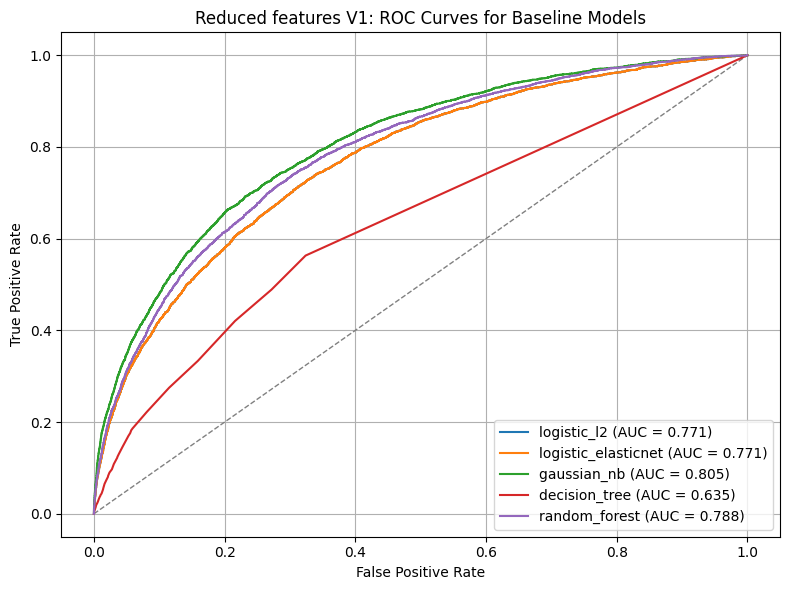

In [ ]:
roc_reduced_v1_results = {}

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)

models_reduced_v1 = {
    "logistic_l2": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l2",
            class_weight="balanced",
            solver="lbfgs",
            max_iter=1000,
            random_state=42
        ))
    ]),

    "logistic_elasticnet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="elasticnet",
            class_weight="balanced",
            solver="saga",
            l1_ratio=0.5,   # baseline value; tune later
            C=1.0,
            max_iter=2000,
            random_state=42
        ))
    ]),

    "gaussian_nb": GaussianNB(),

    "decision_tree": DecisionTreeClassifier(
        max_depth=6,          # shallow baseline
        min_samples_leaf=20,
        random_state=42
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced_subsample",
        max_depth=15,
        min_samples_leaf=20,
        n_jobs=-1,
        random_state=42
    )
}

for name, model in models_reduced_v1.items():
    st = time.time()
    model.fit(X_train_reduced, y_train)
    print(f"{name} model trained in {time.time()-st} seconds.")

    y_proba = model.predict_proba(X_val_reduced)[:, 1]

    auc = roc_auc_score(y_val, y_proba)
    fpr, tpr, _ = roc_curve(y_val, y_proba)

    roc_reduced_v1_results[name] = {
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr
    }

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Reduced features V1: ROC Curves for Baseline Models")
plt.legend(loc="lower right")   # Legend shows model name + AUC
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
redundant_features = rank_df[rank_df["bucket"] == "redundant"].index
X_red = X_train[redundant_features]
corr = X_red.corr(method="spearman").abs()
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

distance = 1 - corr
condensed_dist = squareform(distance.values, checks=False)

Z = linkage(condensed_dist, method="average")
cluster_labels = fcluster(
    Z,
    t=0.15,          # distance threshold
    criterion="distance"
)

cluster_df = pd.DataFrame({
    "feature": redundant_features,
    "cluster": cluster_labels
})

cluster_df = cluster_df.merge(
    rank_df[["rank_perm_mean"]],
    left_on="feature",
    right_index=True
)

# Sort cluster_df so the feature with best permutation importance comes first
# Pick the first feature in each cluster
representatives = cluster_df.sort_values("rank_perm_mean").groupby("cluster")['feature'].first()

# Convert to Index
representatives = pd.Index(representatives.values)

final_features = (
    rank_df[rank_df["bucket"] == "core"].index
    .union(representatives)
    .union(rank_df[rank_df["bucket"] == "weak"].index)
)


In [49]:
rank_df[rank_df["bucket"] == "weak"].shape

(165, 9)

Seems like all 5 have survived the test. I don't know what was I doing anyways.

In [8]:
# from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier # slow, removed for now
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Add new models
models_2 = {
    'xgboost': XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_jobs=-1
    ),
    'lightgbm': LGBMClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ),
    'catboost': CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        random_state=42,
        verbose=0
    ),
    # 'gradient_boosting': GradientBoostingClassifier( # SLOW...
    #     n_estimators=500,
    #     max_depth=6,
    #     learning_rate=0.05,
    #     subsample=0.8,
    #     random_state=42
    # ),
    # 'extra_trees': ExtraTreesClassifier(
    #     n_estimators=200,
    #     max_depth=15, # DONT BURN MY POTATO LAPTOP...
    #     min_samples_leaf=20,
    #     random_state=42,
    #     n_jobs=-1
    # )
}

In [60]:
y_val.value_counts()

target
0    35980
1     4020
Name: count, dtype: int64

c:\Users\User\Documents\Code\python\ml\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:40:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


xgboost model trained in 116.60681319236755 seconds.
[LightGBM] [Info] Number of positive: 16078, number of negative: 143922
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.181169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 50745
[LightGBM] [Info] Number of data points in the train set: 160000, number of used features: 199
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.100487 -> initscore=-2.191820
[LightGBM] [Info] Start training from score -2.191820
lightgbm model trained in 31.76517415046692 seconds.
catboost model trained in 59.04136085510254 seconds.


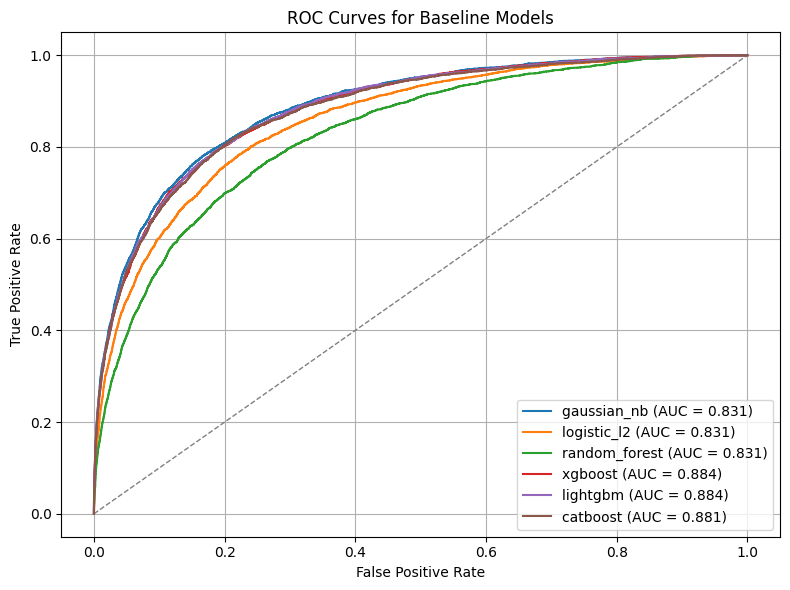

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
# Include top performers from previous ROC (no reduce) graph
plt.plot(roc_results["gaussian_nb"]["fpr"], roc_results["gaussian_nb"]["tpr"], label=f"gaussian_nb (AUC = {roc_results["gaussian_nb"]["auc"]:.3f})")
plt.plot(roc_results["logistic_l2"]["fpr"], roc_results["logistic_l2"]["tpr"], label=f"logistic_l2 (AUC = {roc_results["logistic_l2"]["auc"]:.3f})")
plt.plot(roc_results["random_forest"]["fpr"], roc_results["random_forest"]["tpr"], label=f"random_forest (AUC = {roc_results["random_forest"]["auc"]:.3f})")

for name, model in models_2.items():
    st = time.time()
    model.fit(X_train, y_train)
    print(f"{name} model trained in {time.time()-st} seconds.")

    y_proba = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_proba)
    fpr, tpr, _ = roc_curve(y_val, y_proba)

    roc_results[name] = {
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr
    }

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Baseline Models")
plt.legend(loc="lower right")   # Legend shows model name + AUC
plt.grid(True)
plt.tight_layout()
plt.show()

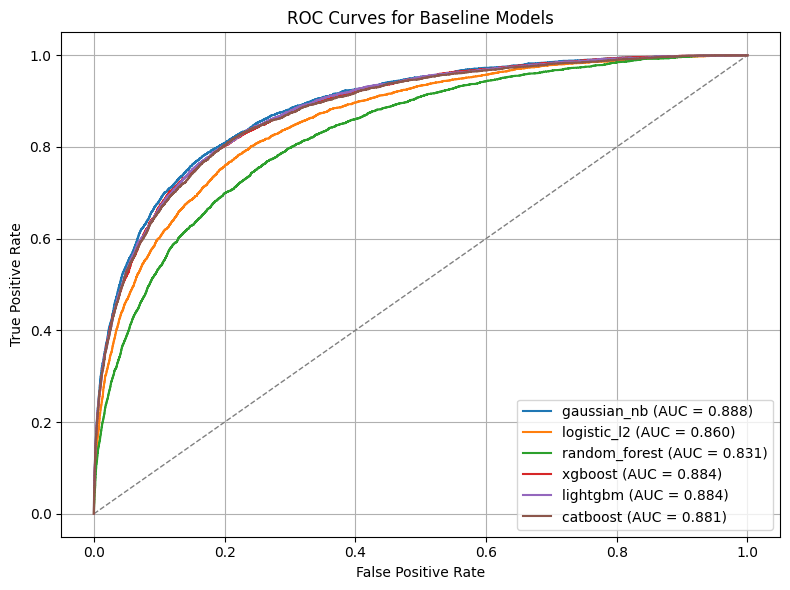

In [13]:
plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
# Include top performers from previous ROC (no reduce) graph
plt.plot(roc_results["gaussian_nb"]["fpr"], roc_results["gaussian_nb"]["tpr"], label=f"gaussian_nb (AUC = {roc_results["gaussian_nb"]["auc"]:.3f})")
plt.plot(roc_results["logistic_l2"]["fpr"], roc_results["logistic_l2"]["tpr"], label=f"logistic_l2 (AUC = {roc_results["logistic_l2"]["auc"]:.3f})")
plt.plot(roc_results["random_forest"]["fpr"], roc_results["random_forest"]["tpr"], label=f"random_forest (AUC = {roc_results["random_forest"]["auc"]:.3f})")
plt.plot(roc_results["xgboost"]["fpr"], roc_results["xgboost"]["tpr"], label=f"xgboost (AUC = {roc_results["xgboost"]["auc"]:.3f})")
plt.plot(roc_results["lightgbm"]["fpr"], roc_results["lightgbm"]["tpr"], label=f"lightgbm (AUC = {roc_results["lightgbm"]["auc"]:.3f})")
plt.plot(roc_results["catboost"]["fpr"], roc_results["catboost"]["tpr"], label=f"catboost (AUC = {roc_results["catboost"]["auc"]:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Baseline Models")
plt.legend(loc="lower right")   # Legend shows model name + AUC
plt.grid(True)
plt.tight_layout()
plt.show()

## Tuning

`gnb`

In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "var_smoothing": np.logspace(-12, -6, 50)
}

gnb = GaussianNB()

rs_gnb = RandomizedSearchCV(
    estimator=gnb,
    param_distributions=param_dist,
    n_iter=25,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rs_gnb.fit(X_train, y_train)

best_gnb = rs_gnb.best_estimator_
print("Best AUC:", rs_gnb.best_score_)
print("Best params:", rs_gnb.best_params_)


Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best AUC: 0.8879660017105848
Best params: {'var_smoothing': np.float64(3.3932217718953296e-08)}


In [18]:
import optuna
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "random_state": 42,
        "early_stopping_rounds": 50,
        "n_jobs": -1
    }

    aucs = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = XGBClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False
        )

        y_proba = model.predict_proba(X_va)[:, 1]
        aucs.append(roc_auc_score(y_va, y_proba))

    return np.mean(aucs)

study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)

study_xgb.optimize(
    objective_xgb,
    n_trials=40,
    show_progress_bar=True
)

print("Best AUC:", study_xgb.best_value)
print("Best params:", study_xgb.best_params)



[I 2025-12-29 17:05:46,811] A new study created in memory with name: no-name-5df0e59e-42a5-488d-acf4-a272bb71fdd4


  0%|          | 0/40 [00:00<?, ?it/s]

[W 2025-12-29 17:10:04,178] Trial 0 failed with parameters: {'n_estimators': 487, 'max_depth': 8, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_lambda': 2.9154431891537547, 'reg_alpha': 0.2537815508265665} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\User\Documents\Code\python\ml\.venv\Lib\site-packages\optuna\study\_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\User\AppData\Local\Temp\ipykernel_2712\3731880897.py", line 32, in objective_xgb
    model.fit(
    ~~~~~~~~~^
        X_tr, y_tr,
        ^^^^^^^^^^^
        eval_set=[(X_va, y_va)],
        ^^^^^^^^^^^^^^^^^^^^^^^^
        verbose=False
        ^^^^^^^^^^^^^
    )
    ^
  File "c:\Users\User\Documents\Code\python\ml\.venv\Lib\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
 

KeyboardInterrupt: 

In [ ]:
best_xgb = XGBClassifier(
    **study_xgb.best_params,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

best_xgb.fit(X_train, y_train)


In [19]:
import lightgbm as lgb

def lgbm_objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",

        "num_leaves": trial.suggest_int("num_leaves", 16, 64),
        "max_depth": trial.suggest_int("max_depth", 3, 8),

        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 50, 300),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),

        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 0.9),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 0.9),
        "bagging_freq": 1,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),

        "is_unbalance": True,
        "n_jobs": -1,
        "verbosity": -1,
        "random_state": 42
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )

        y_pred = model.predict_proba(X_va)[:, 1]
        aucs.append(roc_auc_score(y_va, y_pred))

    return np.mean(aucs)

study = optuna.create_study(direction="maximize")
study.optimize(lgbm_objective, n_trials=40)

print("Best AUC:", study.best_value)
print("Best params:", study.best_params)

[I 2025-12-29 17:10:57,832] A new study created in memory with name: no-name-b086c857-ee9f-48f9-8eaf-05845a5a885a
[I 2025-12-29 17:11:53,756] Trial 0 finished with value: 0.8285774705072558 and parameters: {'num_leaves': 35, 'max_depth': 4, 'min_data_in_leaf': 265, 'lambda_l1': 0.00020410972380601768, 'lambda_l2': 0.7095374494534229, 'feature_fraction': 0.7487690435585493, 'bagging_fraction': 0.8257988457923429, 'learning_rate': 0.015222623520503567, 'n_estimators': 356}. Best is trial 0 with value: 0.8285774705072558.
[I 2025-12-29 17:13:09,818] Trial 1 finished with value: 0.8582886994570487 and parameters: {'num_leaves': 51, 'max_depth': 4, 'min_data_in_leaf': 70, 'lambda_l1': 9.61927017861705e-06, 'lambda_l2': 4.247615047818918, 'feature_fraction': 0.7621698745559226, 'bagging_fraction': 0.8395352913351256, 'learning_rate': 0.022823882788005193, 'n_estimators': 520}. Best is trial 1 with value: 0.8582886994570487.
[I 2025-12-29 17:14:38,124] Trial 2 finished with value: 0.849826850

KeyboardInterrupt: 

Final sanity check

In [9]:
lgbm_best_params = {'num_leaves': 22, 'max_depth': 8, 'min_data_in_leaf': 194, 'lambda_l1': 7.661813360621163e-05, 'lambda_l2': 0.0013408051078389574, 'feature_fraction': 0.8444984920369294, 'bagging_fraction': 0.6292192663760053, 'learning_rate': 0.06357968356004359, 'n_estimators': 647}
final_lgbm_params = {
    **lgbm_best_params,
    "objective": "binary", "metric": "auc", "boosting_type": "gbdt",
    "is_unbalance": True,
    "n_jobs": -1, "random_state": 42, "verbosity": -1
}

lightgbm-tuned model trained in 37.894043922424316 seconds.


NameError: name 'roc_results' is not defined

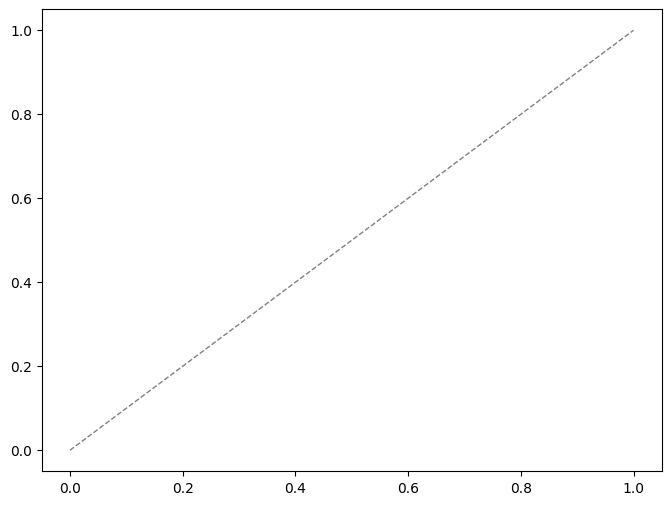

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve
import time
models_3 = {
    'lightgbm-tuned': LGBMClassifier(**final_lgbm_params),
    'gaussian_nb-tuned': GaussianNB(var_smoothing=rs_gnb.best_params_["var_smoothing"])
}

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
# previous candidates
# plt.plot(roc_results["gaussian_nb"]["fpr"], roc_results["gaussian_nb"]["tpr"], label=f"gaussian_nb (AUC = {roc_results["gaussian_nb"]["auc"]:.6f})")
# plt.plot(roc_results["xgboost"]["fpr"], roc_results["xgboost"]["tpr"], label=f"xgboost (AUC = {roc_results["xgboost"]["auc"]:.6f})")
# plt.plot(roc_results["lightgbm"]["fpr"], roc_results["lightgbm"]["tpr"], label=f"lightgbm (AUC = {roc_results["lightgbm"]["auc"]:.6f})")

for name, model in models_3.items():
    st = time.time()
    model.fit(X_train, y_train)
    print(f"{name} model trained in {time.time()-st} seconds.")

    y_proba = model.predict_proba(X_val)[:, 1]

    auc = roc_auc_score(y_val, y_proba)
    fpr, tpr, _ = roc_curve(y_val, y_proba)

    roc_results[name] = {
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr
    }

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.6f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Tuned Models vs Baselines")
plt.legend(loc="lower right")   # Legend shows model name + AUC
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
p_nb = models_3["lightgbm-tuned"].predict_proba(X_val)[:, 1]
p_lgbm = models_3["gaussian_nb-tuned"].predict_proba(X_val)[:, 1]

ensemble_best_score = 0
best_w = -1
for w in [
    # 0.05*i for i in range(1, 20) # curve highest point at 0.4. testing [0.35, 0.45) now
    0.35 + 0.005*i for i in range(1, 20) # found: [0.385, 0.39].
]:
    p_ensemble = w * p_nb + (1-w) * p_lgbm
    ensemble_auc = roc_auc_score(y_val, p_ensemble)
    if ensemble_auc > ensemble_best_score:
        best_w = w
        ensemble_best_score = ensemble_auc
    print(f"Ensemble AUC: {ensemble_auc:.6f}. Current w: {w}.\nCurrent best GNB w: {best_w}, scoring: {ensemble_best_score:.6f}.\n=====")

p_ensemble = 0.385 * p_nb + 0.615 * p_lgbm
ensemble_auc = roc_auc_score(y_val, p_ensemble)
ensemble_auc

0.8941082525117602

OK, the moment of truth...

In [16]:
dataset_test_filepath = Path('.') / 'datasets' / 'test.csv'
df_test_main = pd.read_csv(dataset_test_filepath)

warning: sloppy, unorganized code. objective: give me the dataset with everything done...

In [17]:
df_test_main = df_test_main.drop(columns=["ID_code"])
df_test_main = df_test_main.drop(columns=drop_colnames)

In [18]:
# df_test_main.columns[60:70]
df_train_main = df_train_main.drop(columns=drop_colnames)

In [20]:
X_final = df_train_main.drop(columns=["target"])
y_final = df_train_main["target"]

In [29]:
final_lightgbm = LGBMClassifier(**final_lgbm_params)
final_gaussian_nb = GaussianNB(var_smoothing=rs_gnb.best_params_["var_smoothing"])
final_lightgbm.fit(X_final, y_final)
final_gaussian_nb.fit(X_final, y_final)

,priors,None
,var_smoothing,np.float64(3....718953296e-08)


In [ ]:
# final_lightgbm.predict(df_test_main)
# final_gaussian_nb.predict(df_test_main)

In [30]:
p_final_lgbm = final_lightgbm.predict_proba(df_test_main)[:, 1]
p_final_nb = final_gaussian_nb.predict_proba(df_test_main)[:, 1]
p_ensemble = 0.385 * p_final_nb + 0.615 * p_final_lgbm
final_predictions = (p_ensemble >= 0.5).astype(int)

In [31]:
final_predictions

array([0, 0, 0, ..., 0, 0, 0], shape=(200000,))

In [33]:
# Create ID codes
id_codes = [f"test_{i}" for i in range(len(final_predictions))]

# Build DataFrame
submission_df = pd.DataFrame({
    "ID_code": id_codes,
    "target": final_predictions
})

# Optional: inspect
print(submission_df.head())


  ID_code  target
0  test_0       0
1  test_1       0
2  test_2       0
3  test_3       0
4  test_4       0


In [34]:
submission_df.to_csv("submission.csv", index=False)

In [35]:
# 1. Check shapes
print("X_train shape:", X_train.shape)
print("X_val shape :", X_val.shape)
print("final_predictions shape:", final_predictions.shape)

# 2. Check column names and order
print("\nFirst 10 columns in training set:", list(X_train.columns[:10]))
print("First 10 columns in test set    :", list(X_val.columns[:10]))

# 3. Check data types
print("\nData types in training set:\n", X_train.dtypes.value_counts())
print("Data types in test set:\n", X_val.dtypes.value_counts())

# 4. Check for missing values
print("\nMissing values in training set:", X_train.isna().sum().sum())
print("Missing values in test set    :", X_val.isna().sum().sum())

# 5. Quick sanity check on predictions
print("\nPrediction stats:")
print("min:", np.min(final_predictions))
print("max:", np.max(final_predictions))
print("mean:", np.mean(final_predictions))
print("unique values:", np.unique(final_predictions))

# 6. Optional: compare distributions for first few columns
for col in X_train.columns[:5]:
    print(f"\nColumn {col} summary:")
    print("Train: min/max/mean:", X_train[col].min(), X_train[col].max(), X_train[col].mean())
    print("Test : min/max/mean:", X_val[col].min(), X_val[col].max(), X_val[col].mean())


X_train shape: (160000, 199)
X_val shape : (40000, 199)
final_predictions shape: (200000,)

First 10 columns in training set: ['var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8', 'var_9']
First 10 columns in test set    : ['var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8', 'var_9']

Data types in training set:
 float64    199
Name: count, dtype: int64
Data types in test set:
 float64    199
Name: count, dtype: int64

Missing values in training set: 0
Missing values in test set    : 0

Prediction stats:
min: 0
max: 1
mean: 0.096935
unique values: [0 1]

Column var_0 summary:
Train: min/max/mean: 0.4084 20.315 10.686422776874998
Test : min/max/mean: 0.4528 20.074 10.6538801525

Column var_1 summary:
Train: min/max/mean: -15.0434 10.3768 -1.6350045025
Test : min/max/mean: -14.6962 10.3356 -1.5980904374999998

Column var_2 summary:
Train: min/max/mean: 2.1171 19.353 10.717822088750001
Test : min/max/mean: 2.9462 18.6354 10.7046709
